<a href="https://colab.research.google.com/github/EsserMishelle/hotel-forecast/blob/main/lr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Booking Analysis
This project explores hotel booking demand patterns using a real-world dataset containing reservation information for both city hotels and resort hotels. The goal of the analysis is to understand booking behavior, cancellation patterns, seasonal trends, and factors that influence hotel demand.
## Problem Statement

The hospitality industry operates in a highly competitive environment where understanding customer booking behavior is essential for improving operational efficiency and revenue management. Hotels must analyze patterns in reservations, cancellations, pricing, and customer preferences to make informed business decisions.

This project uses exploratory data analysis (EDA) on a hotel booking dataset to identify trends in demand, customer behavior, and booking characteristics. The analysis aims to uncover insights that can support strategic decision-making related to pricing strategies, marketing efforts, and service improvements.

### Data Description

The dataset contains hotel booking information including customer, reservation, and stay characteristics. Each row represents a single hotel reservation.

Key variables used in the analysis include:

| Column | Description |
|------|-------------|
| hotel | Type of hotel (City Hotel or Resort Hotel) |
| lead_time | Number of days between booking and arrival |
| arrival_date_year | Year of arrival |
| arrival_date_month | Month of arrival |
| stays_in_weekend_nights | Number of weekend nights booked |
| stays_in_week_nights | Number of weekday nights booked |
| adults, children, babies | Number of guests in the reservation |
| market_segment | Market segment category |
| is_canceled | Indicates whether the booking was canceled |
| adr | Average Daily Rate (room price per night) |
| customer_type | Type of customer making the reservation |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import time
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


### Load the Clean Dataset from Google Drive Obtained From Kaggel

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Define folder path within the drive
folder_path = '/content/drive/MyDrive/hotel-forecast'
os.makedirs(folder_path, exist_ok=True)

# Define the assets folder path
assets_folder_path = '/content/drive/MyDrive/hotel-forecast/assets'
os.makedirs(assets_folder_path, exist_ok=True)

Mounted at /content/drive


In [4]:
df= pd.read_csv(os.path.join(folder_path, 'hotels.csv'))

### Exploratory Data Analysis
This section focuses on preparing the dataset for analysis by handling missing values, removing duplicates, and ensuring the data is clean and consistent for further exploration.

Dataset Preview

In [5]:
# Display all columns without skipping
pd.set_option('display.max_columns', None)

display(df.head(5))
display(df.tail(5))

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


Data Types

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

Statiscal Description of Numeric Features

In [7]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Duplicates

In [9]:
len(df[df.duplicated()])

31994

Null Values

In [10]:
# Null value counts
null_counts=df.isnull().sum()

# Null value percentage
null_percentage = round(null_counts/len(df) * 100, 3)

null_summary = pd.DataFrame({'Null count': null_counts, 'Null percentage': null_percentage})
null_summary = null_summary[null_summary['Null count'] > 0]
print(null_summary)

          Null count  Null percentage
children           4            0.003
country          488            0.409
agent          16340           13.686
company       112593           94.307


The hotel DataFrame contains 119,390 entries and 32 columns. It has null values in the following fields: children (4), country (452), agent (12,193), and company (82,137). Additionally, there are 31,994 duplicate entries.

Unique Values

In [11]:
df.nunique()

,0
hotel,2
is_canceled,2
lead_time,479
arrival_date_year,3
arrival_date_month,12
arrival_date_week_number,53
arrival_date_day_of_month,31
stays_in_weekend_nights,17
stays_in_week_nights,35
adults,14


Unique Values in Selected List of Variables

In [12]:
unique_list_cols = ['hotel', 'is_canceled','arrival_date_year', 'adults', 'children',
                    'babies', 'market_segment','distribution_channel',
                    'is_repeated_guest', 'reserved_room_type', 'assigned_room_type',
                    'deposit_type', 'customer_type', 'reservation_status']


In [13]:
for col in unique_list_cols:
    print(f'{col}: {df[col].unique()}')
    print('')

hotel: ['Resort Hotel' 'City Hotel']

is_canceled: [0 1]

arrival_date_year: [2015 2016 2017]

adults: [ 2  1  3  4 40 26 50 27 55  0 20  6  5 10]

children: [ 0.  1.  2. 10.  3. nan]

babies: [ 0  1  2 10  9]

market_segment: ['Direct' 'Corporate' 'Online TA' 'Offline TA/TO' 'Complementary' 'Groups'
 'Undefined' 'Aviation']

distribution_channel: ['Direct' 'Corporate' 'TA/TO' 'Undefined' 'GDS']

is_repeated_guest: [0 1]

reserved_room_type: ['C' 'A' 'D' 'E' 'G' 'F' 'H' 'L' 'P' 'B']

assigned_room_type: ['C' 'A' 'D' 'E' 'G' 'F' 'I' 'B' 'H' 'P' 'L' 'K']

deposit_type: ['No Deposit' 'Refundable' 'Non Refund']

customer_type: ['Transient' 'Contract' 'Transient-Party' 'Group']

reservation_status: ['Check-Out' 'Canceled' 'No-Show']



### Data Cleaning and transformation

Remove Duplicated Transactions

In [14]:
# Make a copy of the raw, original DataFrame and not touch it
# df = df_raw.copy()
# df.shape
df_raw = df.copy()

In [15]:
# Modify df for analysis by dropping duplicates
df.drop_duplicates(inplace=True)

In [16]:
# Confirm the remaining number of transaction is
# original number (119,390) - duplicated number (31,994) = 87396
df.shape

(87396, 32)

The `children` and `agent` columns contain float values, so missing values were replaced with 0.0 to maintain the numeric float structure of the variables.
The `country` column is categorical, therefore missing values were replaced with 'Unknown'. The `company` column contained over 90% missing values and was removed from the dataset as it provides limited analytical value.


In [17]:
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0.0)
df['children'] = df['children'].fillna(0.0)
df.drop(columns = ['company'], inplace = True)

In [24]:
# Confirm no nulls
df.isnull().sum().sum()

np.int64(0)

Transform Datatypes

In [19]:
# Children and Agent should be interger type.
df['children'] = df['children'].astype('int64')
df['agent'] = df['agent'].astype('int64')
# Reservation_status_date should be datetime type
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

In [20]:
# Average daily rate, adr, has a negative value.

df[df['adr'] <0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


In [22]:
# Since it is only 1 row, this transaction is removed.
df.drop(df[df['adr'] <0].index, axis = 0, inplace=True)
display(df[df['adr'] <0])

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


In [23]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395.000000,87395
mean,0.274901,79.890051,2016.210287,26.838526,15.815665,1.005229,2.625356,1.875794,0.138635,0.010824,0.039064,0.030414,0.183969,0.271583,81.002460,0.749574,106.338536,0.084227,0.698575,2016-08-31 03:40:55.348704256
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,72.000000,0.000000,0.000000,2016-03-18 00:00:00
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,98.100000,0.000000,0.000000,2016-09-08 00:00:00
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,0.000000,134.000000,0.000000,1.000000,2017-03-05 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.446467,86.051937,0.686101,13.674531,8.835121,1.031877,2.053564,0.626504,0.455874,0.113597,0.193748,0.369147,1.731893,0.727226,109.944349,10.015788,55.012947,0.281535,0.831947,NaN


**Interpretation:**

*Cancellation Rates:*

The `is_canceled` column has a mean of approximately 0.27 (or 27.0%), suggesting that roughly 27% of bookings were canceled.

*Arrival Dates:*

The columns `arrival_date_year`, `arrival_date_month`, and `arrival_date_day_of_month` show that the entries range from 2015 to 2017.

*Stay Duration:*

The `stays_in_weekend_nights` has an adverage of of 1 night, while `stays_in_week_nights` adverages about 2.62 nights, suggesting that most bookings include more weekdays than weekend nights.

*Adults and Children:*

The `adults` column has a mean of 1.88, indicating that the typical booking is for around 1 to 2 adults. The `children` column shows a mean of 0.13 and `babies` has a mean of 0.01, indicating that most bookings do not include children.

The `adr` variable has an average value of approximately 106, although the maximum value is extremely high (5400), suggesting the presence of outliers that may influence pricing analysis.

The `previous_bookings_not_canceled` has a mean of .18, indicating that most guests do not have a long booking history with the hotel, suggesting that repeat guests represent a relatively small portion of reservations.

### Interpretation

**Cancellation Rates**

The `is_canceled` column has a mean of approximately **0.27 (27%)**, suggesting that roughly **one quarter of bookings were canceled**.

**Arrival Dates**

The columns `arrival_date_year`, `arrival_date_month`, and `arrival_date_day_of_month` indicate that the dataset contains bookings from **2015 to 2017**.

**Stay Duration**

The variable `stays_in_weekend_nights` has an average of **about 1 night**, while `stays_in_week_nights` averages **about 2.62 nights**, suggesting that most bookings include **more weekday nights than weekend nights**.

**Adults and Children**

The `adults` column has a mean of **1.88**, indicating that the typical booking includes **1–2 adults**.  
The variables `children` (mean of 0.13) and `babies` (mean of 0.01) show that **most bookings do not include children or infants**.

**Pricing**

The `adr` (average daily rate) variable has a mean value of approximately **106**, although the maximum value reaches **5400**, suggesting the presence of **extreme outliers that may influence pricing analysis**.

**Customer History**

The `previous_bookings_not_canceled` variable has a mean of **0.18**, indicating that **most guests do not have a long booking history with the hotel**, suggesting repeat guests represent a relatively small share of reservations.

## Feature Engineer

Total stay length

In [25]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

Total guests

In [26]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']

Lead time categories

In [27]:
df['lead_time_group'] = pd.cut(
    df['lead_time'],
    bins=[-1,7,30,90,365,800],
    labels=['last_min', 'short', 'medium', 'long', 'very_long'],
    include_lowest=True,
    right=False
)


Family indicator

In [28]:
df['has_children'] = ((df['children']+ df['babies']) >0).astype(int)

Added variables are created to capture useful booking features such as total stay duration, total number of guests, and booking lead time categories. These engineered features help provide clearer insights during analysis and modeling.

## Charts
### Cancellation by market segment

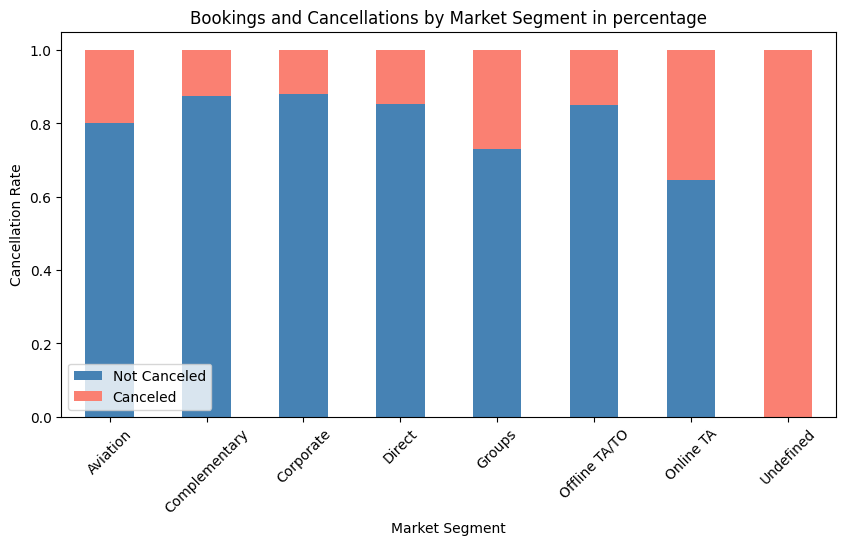

In [53]:
segment_cancel = pd.crosstab(df['market_segment'], df['is_canceled'], normalize='index')

segment_cancel.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5),
    color=['steelblue', 'salmon']
)

plt.title('Bookings and Cancellations by Market Segment in percentage')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate')
plt.legend(['Not Canceled','Canceled'], loc='lower left')
plt.xticks(rotation=45)
plt.show()

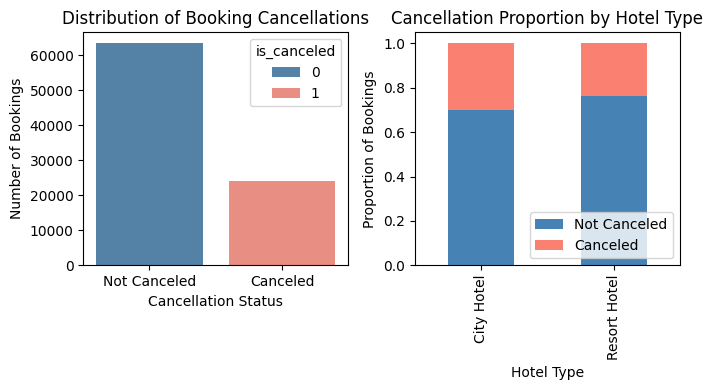

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(7,4))
df['is_canceled_label'] = df['is_canceled'].map({0:'Not Canceled',1:'Canceled'})

# Chart 1: Cancellation distribution
sns.countplot(
    # x='is_canceled',
    x='is_canceled_label',
    hue='is_canceled',
    data=df,
    palette=['steelblue','salmon'],
    ax=ax[0]
)

ax[0].set_title('Distribution of Booking Cancellations')
ax[0].set_xlabel('Cancellation Status')
ax[0].set_ylabel('Number of Bookings')
ax[0].set_xticks([0,1])
ax[0].set_xticklabels(['Not Canceled','Canceled'])

# Chart 2: Cancellation by hotel type
pd.crosstab(df['hotel'], df['is_canceled'], normalize='index').plot(
    kind='bar',
    stacked=True,
    color=['steelblue','salmon'],
    ax=ax[1]
)

ax[1].set_title('Cancellation Proportion by Hotel Type')
ax[1].set_ylabel('Proportion of Bookings')
ax[1].set_xlabel('Hotel Type')
ax[1].legend(['Not Canceled','Canceled'], loc= 'lower right')

plt.tight_layout()
plt.show()

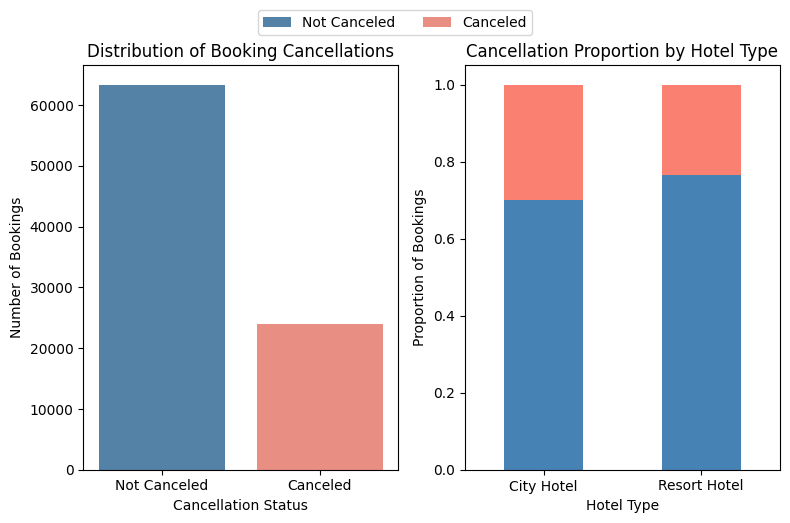

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(8,5))

# Chart 1
sns.countplot(
    x='is_canceled',
    hue='is_canceled',
    data=df,
    palette=['steelblue','salmon'],
    legend=False,
    ax=ax[0]
)

ax[0].set_title('Distribution of Booking Cancellations')
ax[0].set_xlabel('Cancellation Status')
ax[0].set_ylabel('Number of Bookings')
ax[0].set_xticks([0,1])
ax[0].set_xticklabels(['Not Canceled','Canceled'])


# Chart 2
pd.crosstab(df['hotel'], df['is_canceled'], normalize='index').plot(
    kind='bar',
    stacked=True,
    color=['steelblue','salmon'],
    ax=ax[1],
    legend=False
)

ax[1].set_title('Cancellation Proportion by Hotel Type')
ax[1].set_ylabel('Proportion of Bookings')
ax[1].set_xlabel('Hotel Type')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)

# Shared legend
fig.legend(
    ['Not Canceled','Canceled'],
    loc='upper center',
    # loc='lower right',
    bbox_to_anchor=(0.5, 1.05),
    ncol=2

)

plt.tight_layout()
plt.show()

## Model(s)

In [ ]:
# target
y = df['is_canceled']

# features
features = [
    'hotel',
    'lead_time',
    'arrival_date_year',
    'arrival_date_month',
    'arrival_date_week_number',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'meal',
    'country',
    'market_segment',
    'distribution_channel',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'reserved_room_type',
    'booking_changes',
    'deposit_type',
    'agent',
    'days_in_waiting_list',
    'customer_type',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

X = df[features].copy()

# categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# model pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# train
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# evaluate
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n')
print(confusion_matrix(y_test, y_pred))

A Logistic Regression model was used as the initial baseline classifier to predict booking cancellations. Since `is_canceled` is a binary outcome, Logistic Regression provides an interpretable and efficient starting point for evaluating how booking characteristics relate to cancellation behavior.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))
print('\nRandom Forest Classification Report:\n')
print(classification_report(y_test, rf_pred))